Loading the modules

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Loading the dataset

In [2]:
df = pd.read_csv("Source data/train_data.csv")
df.head(5)

,year,month,day,order,country,session_id,page1_main_category,page2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,6,22,21,29,15648,3,C20,13,1,2,48,1,2
1,2008,5,19,6,29,10018,2,B26,13,3,1,57,1,2
2,2008,7,15,2,29,19388,3,C13,9,5,1,48,1,1
3,2008,5,2,2,29,7181,2,B11,2,4,1,43,2,1
4,2008,6,9,16,29,13493,2,B31,9,5,1,57,1,2


Understanding the data

In [3]:
df.shape

(132379, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132379 entries, 0 to 132378
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   year                  132379 non-null  int64 
 1   month                 132379 non-null  int64 
 2   day                   132379 non-null  int64 
 3   order                 132379 non-null  int64 
 4   country               132379 non-null  int64 
 5   session_id            132379 non-null  int64 
 6   page1_main_category   132379 non-null  int64 
 7   page2_clothing_model  132379 non-null  object
 8   colour                132379 non-null  int64 
 9   location              132379 non-null  int64 
 10  model_photography     132379 non-null  int64 
 11  price                 132379 non-null  int64 
 12  price_2               132379 non-null  int64 
 13  page                  132379 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 14.1+ MB


In [5]:
df.describe()

,year,month,day,order,country,session_id,page1_main_category,colour,location,model_photography,price,price_2,page
count,132379.0,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000
mean,2008.0,5.582759,14.507671,9.811314,26.949629,12038.722063,2.400426,6.227393,3.261106,1.260026,43.788191,1.488484,1.712137
std,0.0,1.328064,8.829106,13.458937,7.153071,7012.460866,1.145004,4.238354,1.714058,0.438650,12.539390,0.499869,0.983699
min,2008.0,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000
25%,2008.0,4.000000,7.000000,2.000000,29.000000,5905.000000,1.000000,3.000000,2.000000,1.000000,33.000000,1.000000,1.000000
50%,2008.0,5.000000,14.000000,6.000000,29.000000,11931.000000,2.000000,4.000000,3.000000,1.000000,43.000000,1.000000,1.000000
75%,2008.0,7.000000,22.000000,12.000000,29.000000,18212.000000,3.000000,9.000000,5.000000,2.000000,52.000000,2.000000,2.000000
max,2008.0,8.000000,31.000000,195.000000,47.000000,24026.000000,4.000000,14.000000,6.000000,2.000000,82.000000,2.000000,5.000000


In [6]:
df.dtypes

year                     int64
month                    int64
day                      int64
order                    int64
country                  int64
session_id               int64
page1_main_category      int64
page2_clothing_model    object
colour                   int64
location                 int64
model_photography        int64
price                    int64
price_2                  int64
page                     int64
dtype: object

In [7]:
df.isnull().sum()

year                    0
month                   0
day                     0
order                   0
country                 0
session_id              0
page1_main_category     0
page2_clothing_model    0
colour                  0
location                0
model_photography       0
price                   0
price_2                 0
page                    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

year                        1
month                       5
day                        31
order                     193
country                    46
session_id              22910
page1_main_category         4
page2_clothing_model      216
colour                     14
location                    6
model_photography           2
price                      20
price_2                     2
page                        5
dtype: int64

Data Cleaning

In [10]:
# Drop Duplicates
df.drop_duplicates()

,year,month,day,order,country,session_id,page1_main_category,page2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,6,22,21,29,15648,3,C20,13,1,2,48,1,2
1,2008,5,19,6,29,10018,2,B26,13,3,1,57,1,2
2,2008,7,15,2,29,19388,3,C13,9,5,1,48,1,1
3,2008,5,2,2,29,7181,2,B11,2,4,1,43,2,1
4,2008,6,9,16,29,13493,2,B31,9,5,1,57,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132374,2008,7,4,3,29,17622,4,P19,2,1,1,48,1,2
132375,2008,6,19,9,29,15165,3,C26,14,3,1,28,2,2
132376,2008,7,15,4,29,19359,1,A4,3,2,2,38,2,1
132377,2008,7,28,16,29,21454,3,C50,9,5,2,20,2,3


Exploratory Data Analysis

In [11]:
num = df.select_dtypes(exclude = 'object')

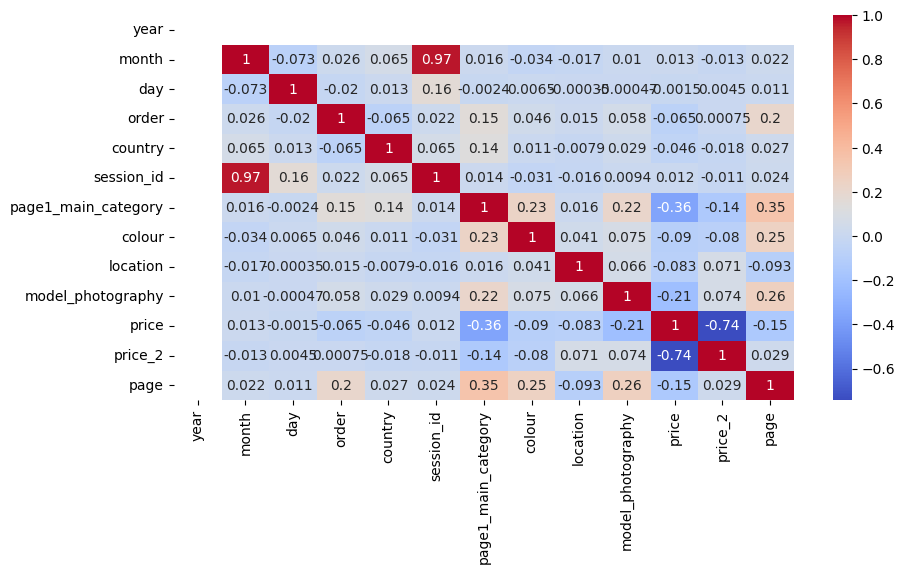

In [12]:
# plot the distribution of numeric columns
plt.figure(figsize = (10,5))
corr = num.corr()
sns.heatmap(corr, cmap = 'coolwarm', annot = True)
plt.show()

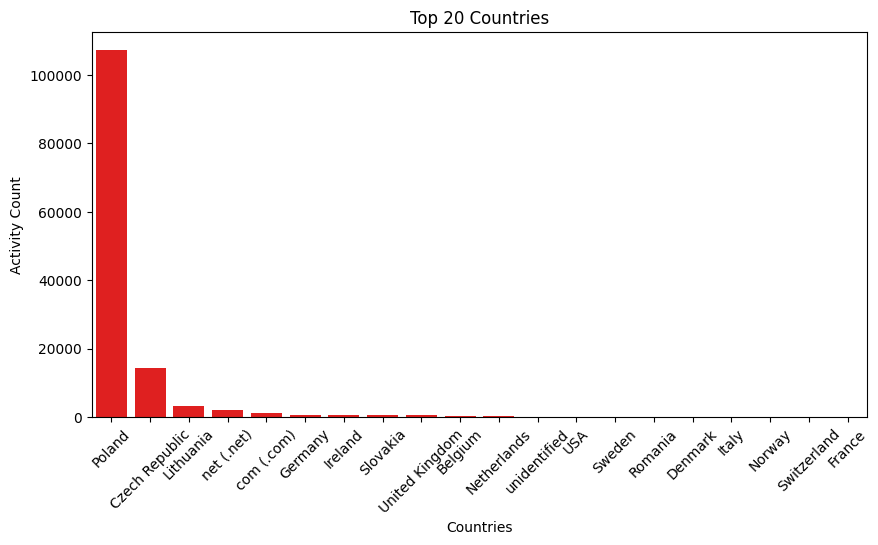

In [13]:
# Histogram of Price Distribution by Country

countries = df['country'].value_counts().head(20)

country_mappings = {'1': 'Australia','2': 'Austria','3': 'Belgium','4': 'British Virgin Islands','5': 'Cayman Islands','6': 'Christmas Island','7': 'Croatia','8': 'Cyprus',
            '9': 'Czech Republic','10': 'Denmark','11': 'Estonia','12': 'unidentified','13': 'Faroe Islands','14': 'Finland','15': 'France','16': 'Germany','17': 'Greece',
            '18': 'Hungary','19': 'Iceland','20': 'India','21': 'Ireland','22': 'Italy','23': 'Latvia','24': 'Lithuania','25': 'Luxembourg','26': 'Mexico','27': 'Netherlands',
            '28': 'Norway','29': 'Poland','30': 'Portugal','31': 'Romania','32': 'Russia','33': 'San Marino','34': 'Slovakia','35': 'Slovenia','36': 'Spain',
            '37': 'Sweden','38': 'Switzerland','39': 'Ukraine','40': 'United Arab Emirates','41': 'United Kingdom','42': 'USA','43': 'biz (.biz)','44': 'com (.com)',
            '45': 'int (.int)','46': 'net (.net)','47': 'org (*.org)'}

countries.index = countries.index.astype(str).map(country_mappings)

# Seaborn barplot of countries

plt.figure(figsize=(10, 5))
sns.barplot(x = countries.index, y = countries.values,color='red')
plt.title('Top 20 Countries')
plt.xlabel('Countries')
plt.ylabel('Activity Count')
plt.xticks(rotation = 45)
plt.show()

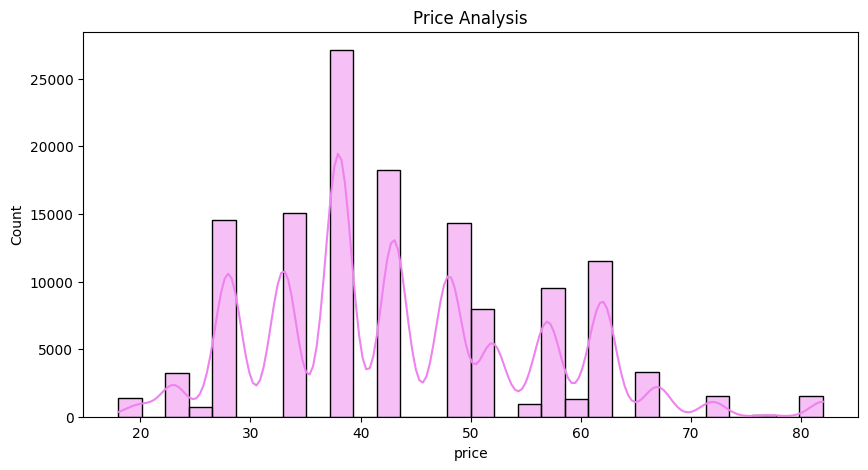

In [14]:
# Histogram of Price Analysis

plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins = 30,kde=True, color = 'Violet')
plt.title("Price Analysis")
plt.show()

Main Product Analysis

In [15]:
mappings = {1:'trousers', 2:'skirts', 3:'blouses', 4:'sale'}
main_prdt = df['page1_main_category'].map(mappings)
main_prdt

0          blouses
1           skirts
2          blouses
3           skirts
4           skirts
            ...   
132374        sale
132375     blouses
132376    trousers
132377     blouses
132378      skirts
Name: page1_main_category, Length: 132379, dtype: object

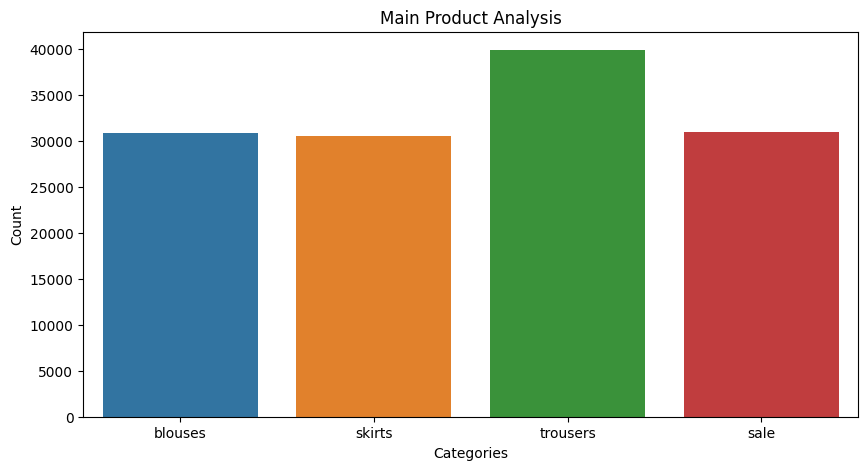

In [16]:
# Seaborn countplot of main product categories

plt.figure(figsize=(10, 5))
sns.countplot(data = df, x = main_prdt, hue = main_prdt)
plt.title('Main Product Analysis')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.show()